In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [16]:
df = pd.read_csv("retail_sales_dataset.csv")

In [17]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100


In [18]:
df.shape

(1000, 9)

In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Transaction ID    1000 non-null   int64
 1   Date              1000 non-null   str  
 2   Customer ID       1000 non-null   str  
 3   Gender            1000 non-null   str  
 4   Age               1000 non-null   int64
 5   Product Category  1000 non-null   str  
 6   Quantity          1000 non-null   int64
 7   Price per Unit    1000 non-null   int64
 8   Total Amount      1000 non-null   int64
dtypes: int64(5), str(4)
memory usage: 100.2 KB


In [20]:
df.describe()

,Transaction ID,Age,Quantity,Price per Unit,Total Amount
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000
mean,500.500000,41.39200,2.514000,179.890000,456.000000
std,288.819436,13.68143,1.132734,189.681356,559.997632
min,1.000000,18.00000,1.000000,25.000000,25.000000
25%,250.750000,29.00000,1.000000,30.000000,60.000000
50%,500.500000,42.00000,3.000000,50.000000,135.000000
75%,750.250000,53.00000,4.000000,300.000000,900.000000
max,1000.000000,64.00000,4.000000,500.000000,2000.000000


In [21]:
df.columns

Index(['Transaction ID', 'Date', 'Customer ID', 'Gender', 'Age',
       'Product Category', 'Quantity', 'Price per Unit', 'Total Amount'],
      dtype='str')

In [22]:
df.drop_duplicates(inplace=True)

In [23]:
df.duplicated().sum()

np.int64(0)

In [52]:
missing_values = df.isnull().sum()

missing_values

Transaction ID      0
Date                0
Customer ID         0
Gender              0
Age                 0
Product Category    0
Quantity            0
Price per Unit      0
Total Amount        0
Month               0
Day                 0
Year                0
dtype: int64

### Observation
No missing values were identified in the dataset, therefore no missing-value treatment was required.

In [46]:
df['Date'] = pd.to_datetime(df['Date'])

In [47]:
df.info

<bound method DataFrame.info of      Transaction ID       Date Customer ID  Gender  Age Product Category  \
0                 1 2023-11-24     CUST001    Male   34           Beauty   
1                 2 2023-02-27     CUST002  Female   26         Clothing   
2                 3 2023-01-13     CUST003    Male   50      Electronics   
3                 4 2023-05-21     CUST004    Male   37         Clothing   
4                 5 2023-05-06     CUST005    Male   30           Beauty   
..              ...        ...         ...     ...  ...              ...   
995             996 2023-05-16     CUST996    Male   62         Clothing   
996             997 2023-11-17     CUST997    Male   52           Beauty   
997             998 2023-10-29     CUST998  Female   23           Beauty   
998             999 2023-12-05     CUST999  Female   36      Electronics   
999            1000 2023-04-12    CUST1000    Male   47      Electronics   

     Quantity  Price per Unit  Total Amount  
0        

In [54]:
df['Month'] = df['Date'].dt.month_name()
df['Day'] = df['Date'].dt.day_name()
df['Year'] = df['Date'].dt.year

In [55]:
df.head()

,Transaction ID,Date,Customer ID,Gender,Age,Product Category,Quantity,Price per Unit,Total Amount,Month,Day,Year
0,1,2023-11-24,CUST001,Male,34,Beauty,3,50,150,November,Friday,2023
1,2,2023-02-27,CUST002,Female,26,Clothing,2,500,1000,February,Monday,2023
2,3,2023-01-13,CUST003,Male,50,Electronics,1,30,30,January,Friday,2023
3,4,2023-05-21,CUST004,Male,37,Clothing,1,500,500,May,Sunday,2023
4,5,2023-05-06,CUST005,Male,30,Beauty,2,50,100,May,Saturday,2023


In [56]:
print("Total Revenue:", df['Total Amount'].sum())
print("Total Transactions:", df['Transaction ID'].nunique())
print("Total Quantity Sold:", df['Quantity'].sum())
print("Average Transaction Value:", df['Total Amount'].mean())

Total Revenue: 456000
Total Transactions: 1000
Total Quantity Sold: 2514
Average Transaction Value: 456.0


In [ ]:
#Feature engineering : Creating new useful variables from existing data to improve analysis.

In [75]:
bins = [0, 25, 35, 45, 55, 100]

labels = [
    'Under 25',
    '25-35',
    '36-45',
    '46-55',
    '55+'
]

df['Age Group'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [76]:
df[['Age', 'Age Group']].head(10)

,Age,Age Group
0,34,25-35
1,26,25-35
2,50,46-55
3,37,36-45
4,30,25-35
5,45,36-45
6,46,46-55
7,30,25-35
8,63,55+
9,52,46-55


In [ ]:
# Exploratory Data Analysis (EDA)

In [44]:
total_revenue = df['Total Amount'].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 456000


In [41]:
total_transactions = df['Transaction ID'].nunique()

print("Total Transactions:", total_transactions)

Total Transactions: 1000


In [42]:
total_customers = df['Customer ID'].nunique()

print("Total Customers:", total_customers)

Total Customers: 1000


In [43]:
total_quantity = df['Quantity'].sum()

print("Total Quantity Sold:", total_quantity)

Total Quantity Sold: 2514


In [ ]:
average_transaction_value = df['Total Amount'].mean()

print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

In [38]:
print("RETAIL SALES KPI SUMMARY")
print("-------------------------")
print(f"Total Revenue: ${total_revenue}")
print(f"Total Transactions: {total_transactions}")
print(f"Total Customers: {total_customers}")
print(f"Total Quantity Sold: {total_quantity}")
print(f"Average Transaction Value: ${average_transaction_value:,.2f}")

RETAIL SALES KPI SUMMARY
-------------------------
Total Revenue: $456000
Total Transactions: 1000
Total Customers: 1000
Total Quantity Sold: 2514
Average Transaction Value: $456.00


In [ ]:
#Analysis 1

In [57]:
category_sales = (
    df.groupby('Product Category')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

category_sales

Product Category
Electronics    156905
Clothing       155580
Beauty         143515
Name: Total Amount, dtype: int64

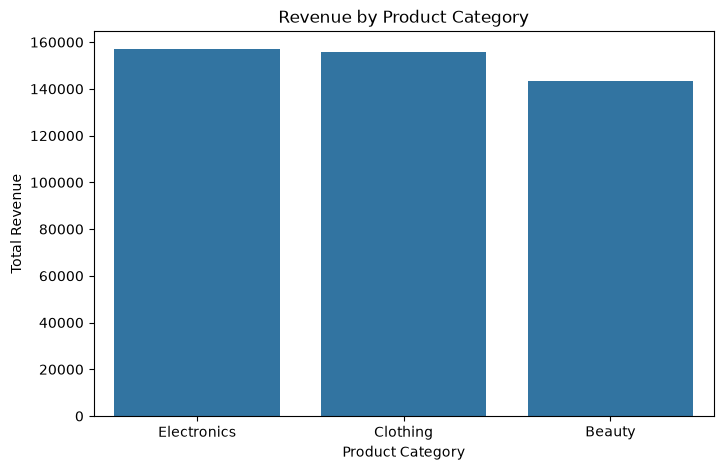

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values
)

plt.title("Revenue by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=0)

plt.show()

In [ ]:
# From the analysis 1 , we have found that electronics is the highest revenue generating product category.

In [ ]:
# Analysis 2 - Quantity Sold by Product Category

In [59]:
category_quantity = (
    df.groupby('Product Category')['Quantity']
    .sum()
    .sort_values(ascending=False)
)

category_quantity

Product Category
Clothing       894
Electronics    849
Beauty         771
Name: Quantity, dtype: int64

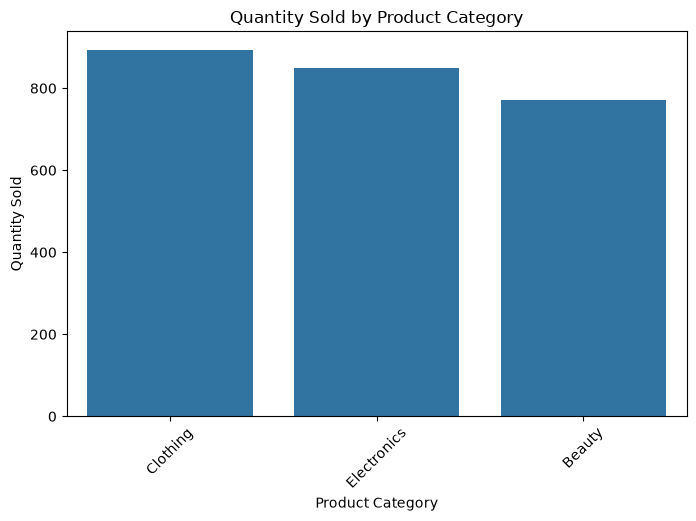

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_quantity.index,
    y=category_quantity.values
)

plt.title("Quantity Sold by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Analysis 3 - Monthly Sales Trend

In [63]:
monthly_sales = (
    df.groupby('Month')['Total Amount']
      .sum()
      .reset_index()
      .sort_values('Month')
)

monthly_sales

,Month,Total Amount
0,April,33870
1,August,36960
2,December,44690
3,February,44060
4,January,36980
5,July,35465
6,June,36715
7,March,28990
8,May,53150
9,November,34920


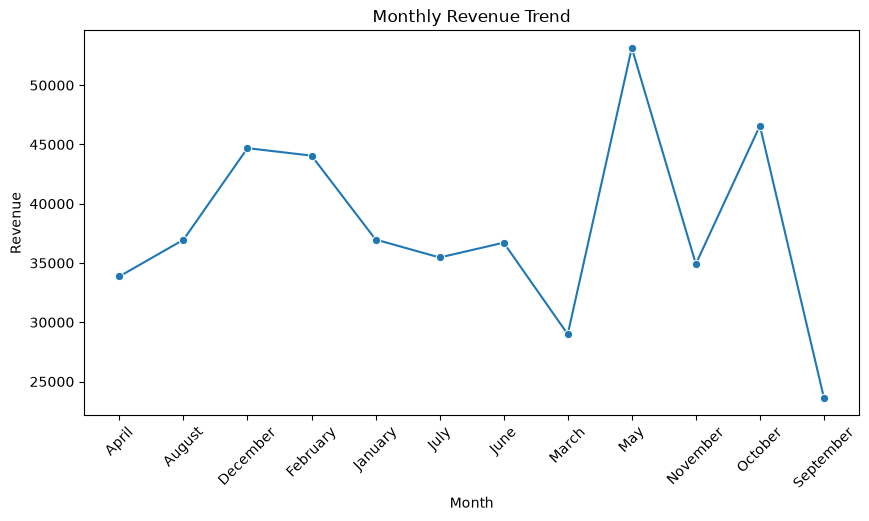

In [64]:
plt.figure(figsize=(10,5))

sns.lineplot(
    data=monthly_sales,
    x='Month',
    y='Total Amount',
    marker='o'
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)

plt.show()

In [65]:
highest_month = monthly_sales.loc[
    monthly_sales['Total Amount'].idxmax()
]

highest_month

Month             May
Total Amount    53150
Name: 8, dtype: object

In [66]:
lowest_month = monthly_sales.loc[
    monthly_sales['Total Amount'].idxmin()
]

lowest_month

Month           September
Total Amount        23620
Name: 11, dtype: object

In [67]:
df['Gender'].value_counts()

Gender
Female    510
Male      490
Name: count, dtype: int64

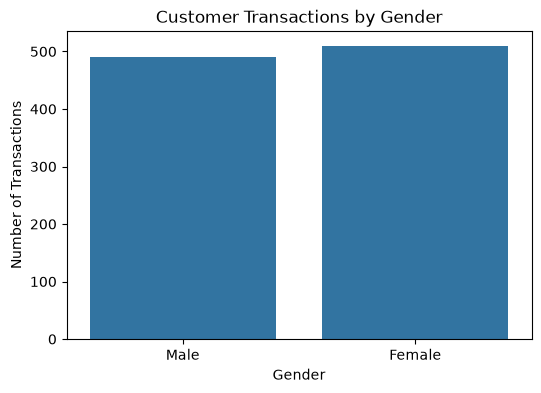

In [68]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x='Gender'
)

plt.title("Customer Transactions by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Transactions")

plt.show()

In [69]:
gender_sales = (
    df.groupby('Gender')['Total Amount']
    .sum()
    .sort_values(ascending=False)
)

gender_sales

Gender
Female    232840
Male      223160
Name: Total Amount, dtype: int64

In [70]:
gender_avg_spending = (
    df.groupby('Gender')['Total Amount']
    .mean()
    .sort_values(ascending=False)
)

gender_avg_spending

Gender
Female    456.549020
Male      455.428571
Name: Total Amount, dtype: float64

In [77]:
age_group_sales = (
    df.groupby(
        'Age Group',
        observed=False
    )['Total Amount']
    .sum()
)

age_group_sales

Age Group
Under 25     84550
25-35        98480
36-45        91870
46-55       100690
55+          80410
Name: Total Amount, dtype: int64

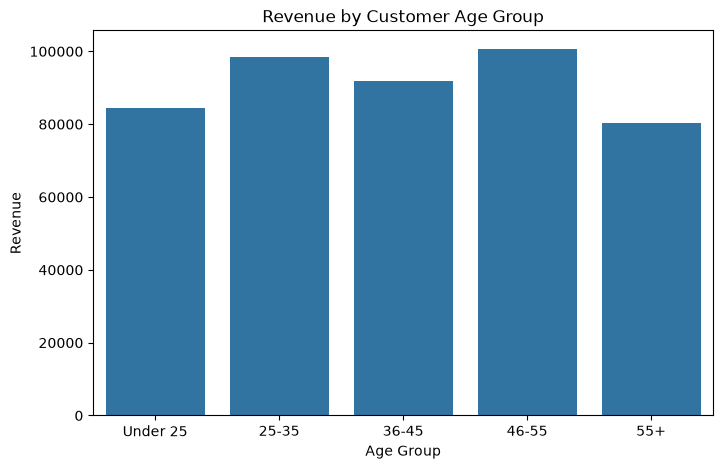

In [80]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=age_group_sales.index,
    y=age_group_sales.values
)

plt.title("Revenue by Customer Age Group")
plt.xlabel("Age Group")
plt.ylabel("Revenue")

plt.show()

In [79]:
avg_category_spend = (
    df.groupby('Product Category')['Total Amount']
    .mean()
    .sort_values(ascending=False)
)

avg_category_spend

Product Category
Beauty         467.475570
Electronics    458.786550
Clothing       443.247863
Name: Total Amount, dtype: float64

In [81]:
numeric_columns = [
    'Age',
    'Quantity',
    'Price per Unit',
    'Total Amount'
]

correlation_matrix = (
    df[numeric_columns]
    .corr()
)

correlation_matrix

,Age,Quantity,Price per Unit,Total Amount
Age,1.000000,-0.023737,-0.038423,-0.060568
Quantity,-0.023737,1.000000,0.017501,0.373707
Price per Unit,-0.038423,0.017501,1.000000,0.851925
Total Amount,-0.060568,0.373707,0.851925,1.000000


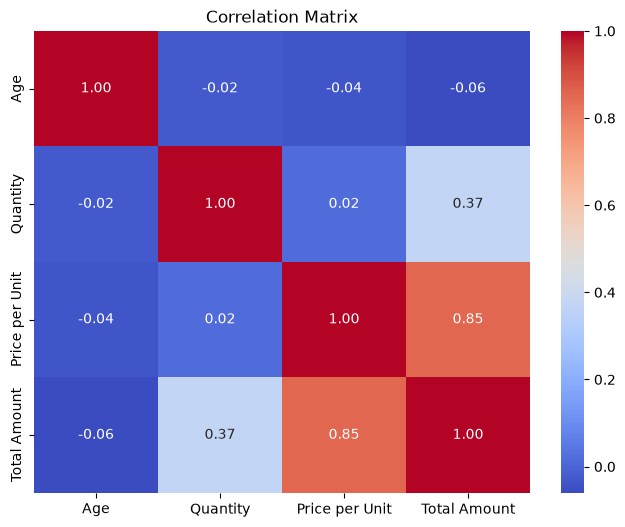

In [82]:
plt.figure(figsize=(8,6))

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title("Correlation Matrix")

plt.show()

In [ ]:
# Conclusion

The project used Python-based Exploratory Data Analysis to examine retail transaction data from multiple business perspectives. Data cleaning, feature engineering, KPI analysis, customer segmentation, correlation analysis, and visualizations were used to identify meaningful sales and customer purchasing patterns.

The analysis demonstrates how retail transaction data can be transformed into actionable business insights that support customer targeting, product strategy, sales planning, and data-driven decision making.